# Лабораторная работа №2

## Задание

По заданию выбрать свои классы и обучить сверточную нейронную сеть из примера, используя GPU, а затем повысить точность модели.

Провести три обучения для 3 разных тактик пуллинга: пуллинг с помощью шага свёртки stride, макс пуллинг, усредняющий пуллинг.

Сравнить достигнутое качество, время обучения и степень переобучения. Выбрать лучшую конфигурацию. Сохранить модель. Перезапустить среду выполнения - теряются все текущие переменные.

Загрузить в colab готовую уже обученную на cifar100 модель. Преобразовать в onnx и сохранить локально.

Скачать [каталог](https://github.com/iu5git/Deep-learning/blob/main/ONNX_script) с html-файлом и встроить в него два файла моделей - обученные на ЛР1 и на ЛР2.

Скачать картинки из интернета согласно варианту и открыть их в html по кнопке. Изображение в скрипте масштабируется автоматически.

Выбрать в js нужные классы для готовой модели. Проверить на устойчивость обе модели (полносвязную и свёрточную) двигая картинку; убедиться в наличии свойства инвариантности сверточного слоя.

Отчет должен содержать: титульный лист, задание с вариантом, скриншоты и краткие пояснения по каждому этапу лабораторной работы, результаты работы модели ONNX в скрипте в браузере на загруженных изображениях, итоговую таблицу с результатами для всех вариантов обучения.

Варианты классов использовать из 1 лабораторной работы.

Дополнительно можно ознакомиться с визуализацией функции потерь Loss landscape.

## Задания для самостоятельной работы
1. Проанализируйте результаты обучения вашей модели. Как изменилась точность на обучающей и тестовой выборке по сравнению с полносвязной моделью?
2. Измените вашу модель - сравните три варианта пуллинга по заданию. Сравните результаты обучения этих 3-х вариантов;
3. Измените вашу модель - поменяйте количество сверточных слоев, размер ядра свертки, шаг свертки и заполнение. Проанализируйте результаты обучения;
4. Возникает ли переобучение вашей модели?
5. Измените гиперпараметры обучения для повышения точности модели: количество эпох, размер батча, скорость обучения;
6. Сравните полносвязную и сверточную нейронную сеть с помощью [визуализации](https://github.com/iu5git/Deep-learning/blob/main/ONNX_script). Сравните результаты моделей и их реакцию на сдвиги изображения. Укажите в отчете отличия моделей и поясните их;
7. Укажите, какие действия помогли повысить точность вашей модели и объясните почему.

## Контрольные вопросы для защиты
1. Сверточная нейронная сеть: объясните структуру, вычисления и назначение слоев и выполняемые преобразования;
2. Что такое свертка, размер ядра, шаг, заполнение? Объясните назначение;
3. Сравните количество нейронов, связей и параметров в полносвязной и сверточной нейронных сетях;
4. Объясните алгоритм оптимизации с моментом. В каких случаях применяется?
5. Свойства свертки.

# Часть 1. Классификация изображений CIFAR100

## Импортирование необходимых библиотек

In [1]:
#!pip install torchsummary
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary
import pickle
import sklearn
from sklearn.metrics import classification_report
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
%matplotlib inline
import sys

In [2]:
# ========== ВЕРСИИ БИБЛИОТЕК ==========
print("=" * 50)
print("ВЕРСИИ БИБЛИОТЕК:")
print("=" * 50)

print(f"Python:          {sys.version.split()[0]}")
print(f"NumPy:           {np.__version__}")
print(f"Matplotlib:      {plt.matplotlib.__version__}")
print(f"Pillow:          {Image.__version__}")
print(f"Scikit-learn:    {sklearn.__version__}")
print(f"PyTorch:         {torch.__version__}")
print(f"  └─ CUDA:       {torch.version.cuda if torch.cuda.is_available() else 'не доступен'}")
print(f"  └─ cuDNN:      {torch.backends.cudnn.version() if torch.cuda.is_available() else 'не доступен'}")
print("=" * 50)

ВЕРСИИ БИБЛИОТЕК:
Python:          3.12.13
NumPy:           2.0.2
Matplotlib:      3.10.0
Pillow:          11.3.0
Scikit-learn:    1.6.1
PyTorch:         2.11.0+cu128
  └─ CUDA:       12.8
  └─ cuDNN:      91900


Актуально для среды выполнения Colab v2026.4 (сменить среду выполнения -> Версия среды выполнения)
- Python:          3.12.13
- NumPy:           2.0.2
- Matplotlib:      3.10.0
- Pillow:          11.3.0
- Scikit-learn:    1.6.1
- PyTorch:         2.11.0+cpu
-  └─ CUDA:       12.8
-  └─ cuDNN:      91900

## Определяем видеокарту GPU, чтобы на ней учить нейронную сеть

In [3]:
!nvidia-smi

Tue Jun 23 08:33:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Загрузка и распаковка набора данных CIFAR100

In [5]:
# Использовать ли зеркало 'Kaggle' для загрузки
DOWNLOAD_FROM_KAGGLE = True
DATASET_PATH = 'cifar-100-python/train'

if DOWNLOAD_FROM_KAGGLE:
  import os
  import kagglehub

  # Download latest version
  path = kagglehub.dataset_download("fedesoriano/cifar100")

  print("Path to dataset files:", path)

  # Посмотрим, что там внутри
  print("Файлы в папке:", os.listdir(path))

  # Если там папка cifar-100-python
  if "cifar-100-python" in os.listdir(path):
      data_path = os.path.join(path, "cifar-100-python")
  else:
      data_path = path

  # Загружаем данные напрямую
  with open(os.path.join(data_path, 'train'), 'rb') as f:
      data_train = pickle.load(f, encoding='latin1')

  with open(os.path.join(data_path, 'test'), 'rb') as f:
      data_test = pickle.load(f, encoding='latin1')

  print("Train keys:", data_train.keys())
  print("Test keys:", data_test.keys())

  DATASET_PATH = path # "/root/.cache/kagglehub/datasets/fedesoriano/cifar100/versions/1"

else:
  !wget https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
  !tar -xvzf cifar-100-python.tar.gz

Using Colab cache for faster access to the 'cifar100' dataset.
Path to dataset files: /kaggle/input/cifar100
Файлы в папке: ['meta', 'file.txt', 'test', 'train']
Train keys: dict_keys(['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data'])
Test keys: dict_keys(['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data'])


## Чтение тренировочной и тестовой выборки

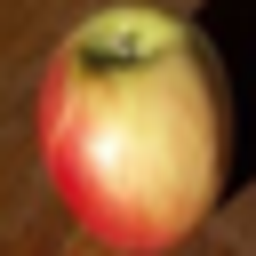

In [6]:
# Здесь указать ваши классы по варианту!!!
CLASSES = [0, 55, 58]


# Обучающая выборка
with open(os.path.join(DATASET_PATH, 'train'), 'rb') as f:
    data_train = pickle.load(f, encoding='latin1')

train_y = np.array(data_train['fine_labels'])
mask = np.isin(train_y, CLASSES)

# Сначала фильтруем данные (работаем с плоским массивом)
train_y_filtered = train_y[mask].copy()
train_X_flat = data_train['data'][mask].copy()

# Теперь преобразуем в формат NCHW (каналы-первыми) — нативный для PyTorch
train_X = train_X_flat.reshape(-1, 3, 32, 32)  # (N, 3, 32, 32) — NCHW
# Для визуализации будем использовать np.transpose на месте
# train_X_nhwc = np.transpose(train_X, [0, 2, 3, 1]) — делаем только при отрисовке

# Перекодируем метки в 0, 1, 2
train_y = np.unique(train_y_filtered, return_inverse=1)[1]
del data_train, train_y_filtered, train_X_flat


# Тестовая выборка (аналогично)
with open(os.path.join(DATASET_PATH, 'test'), 'rb') as f:
    data_train = pickle.load(f, encoding='latin1')

test_y = np.array(data_test['fine_labels'])
mask = np.isin(test_y, CLASSES)

test_y_filtered = test_y[mask].copy()
test_X_flat = data_test['data'][mask].copy()

test_X = test_X_flat.reshape(-1, 3, 32, 32)  # (N, 3, 32, 32) — NCHW

test_y = np.unique(test_y_filtered, return_inverse=1)[1]
del data_test, test_y_filtered, test_X_flat


# Для отображения изображения временно меняем порядок осей NCHW → NHWC
Image.fromarray(np.transpose(train_X[50], [1, 2, 0])).resize((256, 256))

## Создание Pytorch DataLoader'a

In [7]:
batch_size = 128
dataloader = {}

for (X, y), part in zip([(train_X, train_y), (test_X, test_y)],
                        ['train', 'test']):
    # Данные уже в формате NCHW (каналы-первыми) — нативном для PyTorch
    tensor_x = torch.Tensor(X)  # (N, 3, 32, 32)

    # One-hot кодировка для меток
    tensor_y = F.one_hot(torch.Tensor(y).to(torch.int64),
                         num_classes=len(CLASSES)).float()  # .float() вместо /1.

    dataset = TensorDataset(tensor_x, tensor_y)
    dataloader[part] = DataLoader(dataset, batch_size=batch_size, shuffle=True)

dataloader

{'train': <torch.utils.data.dataloader.DataLoader at 0x7da6cdbcef90>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x7da6cdbee720>}

## Создание Pytorch модели сверточной нейронной сети

In [8]:
class Normalize(nn.Module):
    """
    Слой нормализации изображений.
    Приводит пиксели к стандартному нормальному распределению (среднее=0, std=1).
    Ожидает вход в формате NCHW (каналы-первыми) и возвращает его же.
    """
    def __init__(self, mean, std):
        super(Normalize, self).__init__()
        # Сохраняем mean и std как тензоры на нужном устройстве
        # mean и std приводим к виду (C, 1, 1) для корректного broadcasting
        # Регистрируем как буферы (не параметры, но переносятся вместе с моделью)
        self.register_buffer('mean', torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1))
        self.register_buffer('std', torch.tensor(std, dtype=torch.float32).view(-1, 1, 1))

    def forward(self, input):
        # 1. Нормализуем значения пикселей из диапазона [0, 255] в [0, 1]
        x = input / 255.0
        # 2. Центрируем данные: вычитаем среднее (теперь среднее = 0)
        x = x - self.mean
        # 3. Масштабируем: делим на стандартное отклонение (теперь std = 1)
        x = x / self.std
        return x


class GlobalMaxPool2d(nn.Module):
    """
    Слой глобального макспулинга.
    Превращает каждый канал в одно максимальное значение.
    Вход: (N, C, H, W) → Выход: (N, C)
    """
    def __init__(self):
        super(GlobalMaxPool2d, self).__init__()

    def forward(self, input):
        # Применяем AdaptiveMaxPool2d с выходным размером 1x1 для каждого канала
        out = F.adaptive_max_pool2d(input, output_size=1)  # (N, C, 1, 1)
        # Убираем размерности 1x1, оставляя только (N, C)
        return out.flatten(start_dim=1)


# https://blog.jovian.ai/image-classification-of-cifar100-dataset-using-pytorch-8b7145242df1
class Cifar100_CNN(nn.Module):
    """
    Простая свёрточная нейронная сеть (CNN) для классификации CIFAR-100.
    Архитектура: Conv -> ReLU -> Conv -> ReLU -> Pooling -> Flatten -> Linear
    """
    def __init__(self, hidden_size=32, classes=100, mean=None, std=None):
        super(Cifar100_CNN, self).__init__()

        # Если mean и std не переданы — используем стандартные для всего CIFAR-100
        if mean is None:
            mean = [0.5074, 0.4867, 0.4411]
        if std is None:
            std = [0.2011, 0.1987, 0.2025]

        self.seq = nn.Sequential(
            Normalize(mean, std),

            # первый способ уменьшения размерности картинки - через stride
            #    stride=4 и padding=2 для уменьшения размерности с 32x32 до 8x8
            nn.Conv2d(3, hidden_size, kernel_size=5, stride=4, padding=2),
            nn.ReLU(),

            # второй способ уменьшения размерности картинки - через слой пуллинг
            nn.Conv2d(hidden_size, hidden_size*2, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(4),

            # Сплющивание: (N, hidden_size*2, 2, 2) -> (N, hidden_size*8)
            nn.Flatten(),
            # Полносвязный слой: hidden_size*8 -> classes (логиты)
            nn.Linear(hidden_size*8, classes),
        )

    def forward(self, input):
        return self.seq(input)

In [9]:
HIDDEN_SIZE = 32

# Пересчитываем mean и std для нашей выборки
train_X_nchw = train_X  # уже NCHW
custom_mean = train_X_nchw.mean(axis=(0, 2, 3)).astype(np.float32) / 255.0
custom_std = train_X_nchw.std(axis=(0, 2, 3)).astype(np.float32) / 255.0

print(f"Пересчитанные mean: {custom_mean}")
print(f"Пересчитанные std: {custom_std}")

# Создаём модель с пересчитанными статистиками
model = Cifar100_CNN(
    hidden_size=HIDDEN_SIZE,
    classes=len(CLASSES),
    mean=custom_mean,
    std=custom_std
)

# Переносим модель на устройство (GPU/CPU)
model = model.to(device)

# Проверка: прямой проход с случайным тензором в формате NCHW
dummy_input = torch.randn(1, 3, 32, 32).to(device)
print(f"Выход модели: {model(dummy_input).shape}")

# Вывод архитектуры модели
summary(model, input_size=(3, 32, 32))

Пересчитанные mean: [0.53117317 0.4788335  0.4321059 ]
Пересчитанные std: [0.26935863 0.27282682 0.27894792]
Выход модели: torch.Size([1, 3])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         Normalize-1            [-1, 3, 32, 32]               0
            Conv2d-2             [-1, 32, 8, 8]           2,432
              ReLU-3             [-1, 32, 8, 8]               0
            Conv2d-4             [-1, 64, 8, 8]          18,496
              ReLU-5             [-1, 64, 8, 8]               0
         AvgPool2d-6             [-1, 64, 2, 2]               0
           Flatten-7                  [-1, 256]               0
            Linear-8                    [-1, 3]             771
Total params: 21,699
Trainable params: 21,699
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.12
Params size (MB): 0.08

## Выбор функции потерь и оптимизатора градиентного спуска

In [10]:
criterion = nn.CrossEntropyLoss()

# используется SGD c momentum
optimizer = optim.SGD(model.parameters(), lr=5e-3, momentum=0.9)

## Обучение модели по эпохам

  0%|          | 0/6000 [00:00<?, ?it/s]

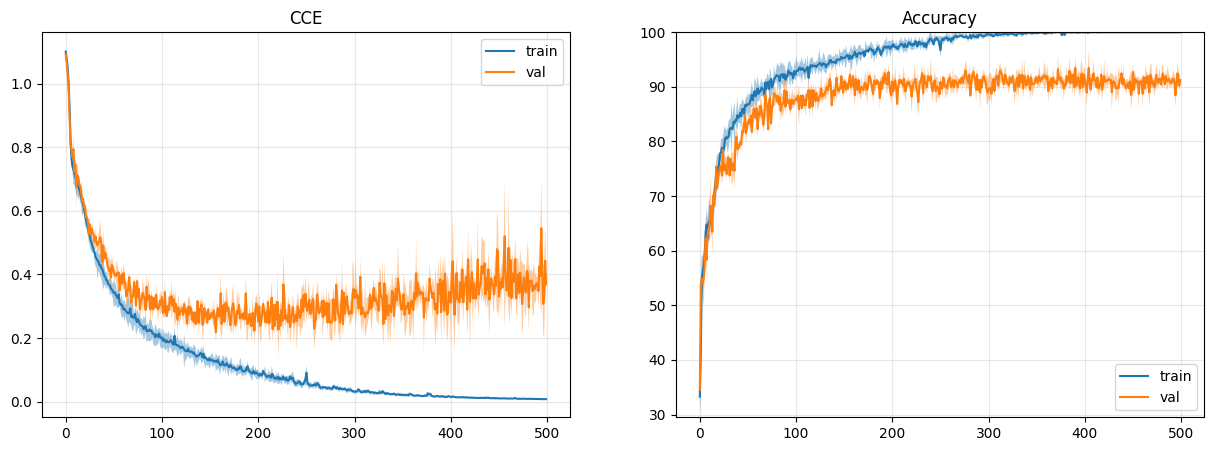

Обучение закончено за 30.208121061325073 секунд


In [11]:
EPOCHS = 500
# перерисовывать графики каждые X эпох
REDRAW_EVERY = int(EPOCHS // 10)

steps_per_epoch = len(dataloader['train'])
steps_per_epoch_val = len(dataloader['test'])

# НОВОЕ - прогресс-бар
pbar = tqdm(total=EPOCHS * steps_per_epoch)  # общее количество итераций
losses = []       # история ошибок на обучении
losses_val = []   # история ошибок на валидации
passed = 0        # общее время обучения

for epoch in range(EPOCHS):
    tmp = []  # временный список для сбора метрик за эпоху
    model.train()

    for i, batch in enumerate(dataloader['train'], 0):
        inputs, labels = batch

        # перенос на GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # очищение прошлых градиентов с прошлой итерации
        optimizer.zero_grad()
        # прямой + обратный проходы + оптимизация
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Считаем accuracy для батча
        # labels.argmax(dim=-1) — one-hot - индексы классов
        accuracy = (labels.argmax(dim=-1) == outputs.argmax(dim=-1)).float().mean().cpu() * 100
        tmp.append((loss.item(), accuracy.item()))
        pbar.update(1)

    # Сохраняем статистики за эпоху: среднее, 25-й и 75-й перцентили
    losses.append((
        np.mean(tmp, axis=0),
        np.percentile(tmp, 25, axis=0),
        np.percentile(tmp, 75, axis=0)
    ))

    # ---------- ВАЛИДАЦИЯ ----------
    tmp = []
    model.eval()
    with torch.no_grad():
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            accuracy = (labels.argmax(dim=-1) == outputs.argmax(dim=-1)).float().mean().cpu() * 100
            tmp.append((loss.item(), accuracy.item()))

    losses_val.append((
        np.mean(tmp, axis=0),
        np.percentile(tmp, 25, axis=0),
        np.percentile(tmp, 75, axis=0)
    ))

    # визуализация
    # каждые REDRAW_EVERY эпох
    if (epoch + 1) % REDRAW_EVERY != 0:
        continue

    clear_output(wait=False)
    passed += pbar.format_dict['elapsed']
    pbar = tqdm(total=EPOCHS * steps_per_epoch, miniters=5)
    pbar.update((epoch + 1) * steps_per_epoch)

    # Рисуем графики
    x_vals = np.arange(epoch + 1)
    _, ax = plt.subplots(1, 2, figsize=(15, 5))
    stats = np.array(losses)
    stats_val = np.array(losses_val)

    ax[1].set_ylim(stats_val[:, 0, 1].min() - 5, 100)  # Accuracy в пределах 0-100
    ax[1].grid(axis='y')

    for i, title in enumerate(['CCE', 'Accuracy']):
        ax[i].plot(x_vals, stats[:, 0, i], label='train')
        ax[i].fill_between(x_vals, stats[:, 1, i], stats[:, 2, i], alpha=0.4)
        ax[i].plot(x_vals, stats_val[:, 0, i], label='val')
        ax[i].fill_between(x_vals, stats_val[:, 1, i], stats_val[:, 2, i], alpha=0.4)
        ax[i].legend()
        ax[i].set_title(title)
        ax[i].grid(True, alpha=0.3)

    plt.show()

print(f'Обучение закончено за {passed} секунд')

## Проверка качества модели по классам на обучающей и тестовой выборках

In [12]:
for part in ['train', 'test']:
    y_pred = []  # список для предсказаний модели
    y_true = []  # список для истинных меток

    with torch.no_grad():  # отключаем градиенты (экономия памяти)
        for i, data in enumerate(dataloader[part], 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)  # перенос на GPU

            outputs = model(inputs)

            # Переносим на CPU и преобразуем в numpy
            y_pred.append(outputs.cpu().detach().numpy())
            y_true.append(labels.cpu().numpy())

    # Объединяем предсказания и метки по всем батчам
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    print(part)
    print(classification_report(
        y_true.argmax(axis=-1),      # true: one-hot - индексы классов
        y_pred.argmax(axis=-1),      # pred: логиты - argmax - индексы
        digits=4,
        target_names=list(map(str, CLASSES))  # подписи классов
    ))
    print('-' * 50)

train
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       500
          55     1.0000    1.0000    1.0000       500
          58     1.0000    1.0000    1.0000       500

    accuracy                         1.0000      1500
   macro avg     1.0000    1.0000    1.0000      1500
weighted avg     1.0000    1.0000    1.0000      1500

--------------------------------------------------
test
              precision    recall  f1-score   support

           0     0.9167    0.9900    0.9519       100
          55     0.8990    0.8900    0.8945       100
          58     0.9247    0.8600    0.8912       100

    accuracy                         0.9133       300
   macro avg     0.9135    0.9133    0.9125       300
weighted avg     0.9135    0.9133    0.9125       300

--------------------------------------------------


# Часть 2. Сохранение модели

## Сохранение и загрузка моделей PyTorch

Бывает так что обучение занимает немало времени и прерывать его нельзя. Для этого удобно периодически сохранять веса модели чтобы в любой момент можно было восстановить прогресс и продолжить обучение с той же точки. Готовую модель также удобно сохранить, чтобы использовать для предсказаний без переобучения или чтобы передавать его между устройствами.

**Способ 1: Только параметры (рекомендуется)**
Сохраняются только веса, архитектура создаётся отдельно. Надёжно, переносимо, безопасно.

- `model.state_dict()` — словарь весов модели
- `torch.save(..., PATH)` — сохраняет словарь
- `model.load_state_dict(torch.load(PATH))` — загружает веса
- `map_location=device` — явно указывает, куда загружать (CPU/GPU)

```python
PATH = 'cifar_cnn.pth'
torch.save(model.state_dict(), PATH)

new_model = Cifar100_CNN(hidden_size=HIDDEN_SIZE, classes=len(CLASSES))
new_model.load_state_dict(torch.load(PATH, map_location=device))
new_model.to(device)
new_model.eval()
```

In [13]:
# Сохранение параметров (рекомендуемый способ)
PATH = 'cifar_cnn.pth'
torch.save(model.state_dict(), PATH)

# Загрузка параметров в новую модель
new_model = Cifar100_CNN(hidden_size=HIDDEN_SIZE, classes=len(CLASSES))
new_model.load_state_dict(torch.load(PATH, map_location=device))  # явно указываем device
new_model.to(device)
new_model.eval()

Cifar100_CNN(
  (seq): Sequential(
    (0): Normalize()
    (1): Conv2d(3, 32, kernel_size=(5, 5), stride=(4, 4), padding=(2, 2))
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=4, stride=4, padding=0)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=256, out_features=3, bias=True)
  )
)

**Способ 2: Вся архитектура (не рекомендуется)**
Сохраняется и архитектура, и веса. Удобно, но небезопасно и ненадёжно (может сломаться при смене версий PyTorch или структуры классов).

- `torch.save(model, PATH)` — сохраняет объект модели целиком
- `torch.load(PATH, weights_only=False)` — загружает модель
- `weights_only=False` — необходимо в PyTorch 2.6+ для загрузки полного объекта

```python
PATH2 = 'cifar_cnn.pt'
torch.save(model, PATH2)

new_model_2 = torch.load(PATH2, weights_only=False, map_location=device)
new_model_2.to(device)
new_model_2.eval()
```

**Аргументы:**
- `PATH` — строка с путём к файлу (например `'model.pth'`)
- `map_location` — устройство для загрузки (`'cpu'`, `'cuda'` или `device`)
- `weights_only` — в PyTorch 2.6+ по умолчанию `True` (безопасная загрузка). Для полной модели ставьте `False`

In [14]:
# Сохранение всей архитектуры (НЕ РЕКОМЕНДУЕТСЯ)
# В PyTorch 2.6+ по умолчанию weights_only=True для безопасности
# Если нужно сохранить всю архитектуру, добавляем weights_only=False
PATH2 = 'cifar_cnn.pt'
torch.save(model, PATH2)

# НОВЫЙ СПОСОБ загрузки (с weights_only=False)
new_model_2 = torch.load(PATH2, weights_only=False, map_location=device)
new_model_2.to(device)
new_model_2.eval()

Cifar100_CNN(
  (seq): Sequential(
    (0): Normalize()
    (1): Conv2d(3, 32, kernel_size=(5, 5), stride=(4, 4), padding=(2, 2))
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AvgPool2d(kernel_size=4, stride=4, padding=0)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=256, out_features=3, bias=True)
  )
)

## Сохранение модели в ONNX

**ONNX (Open Neural Network Exchange)**

ONNX - это открытый формат для представления моделей машинного обучения, который позволяет переносить обученные модели между различными фреймворками (PyTorch, TensorFlow, Caffe и др.). Вместо того чтобы хранить модель в проприетарном формате конкретной библиотеки, ONNX предоставляет единый стандарт, описывающий граф вычислений и обученные веса.

Это делает модели независимыми от фреймворка, упрощает развертывание в проде (особенно на устройствах с ограниченными ресурсами) и позволяет использовать специализированные ONNX Runtime для ускорения инференса на CPU и GPU. ONNX поддерживает аппаратно-зависимые оптимизации и квантование.

In [15]:
!pip install onnx onnxscript onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.3 MB/s eta 0:00:00


**Экспорт модели в ONNX**

В PyTorch есть два способа экспорта: **старый** (TorchScript) и **новый** (Dynamo).

**Параметр `dynamo`**:
- `dynamo=False` — старый экспортёр, надёжнее работает со сложными моделями, но считается устаревшим
- `dynamo=True` — новый экспортёр, быстрее и умнее, но иногда "капризничает" на нестандартных моделях

**Оба способа пока поддерживаются.** Для стабильности в лабораторной используем `dynamo=False` с актуальной версией ONNX.

In [16]:
# Входной тензор для модели
x = torch.randn(1, 3, 32, 32, requires_grad=True).to(device)
torch_out = model(x)

# Экспорт модели
torch.onnx.export(model,               # модель
                  x,                   # входной тензор (или кортеж нескольких тензоров)
                  "cifar100_CNN.onnx", # куда сохранить (либо путь к файлу либо fileObject)
                  export_params=True,  # сохраняет веса обученных параметров внутри файла модели
                  opset_version=18,    # версия ONNX
                  dynamo=False,        # отключает новый torch.onnx.dynamo exporter
                  do_constant_folding=True,  # следует ли выполнять укорачивание констант для оптимизации
                  input_names = ['input'],   # имя входного слоя
                  output_names = ['output'],  # имя выходного слоя
                  dynamic_axes={'input' : {0 : 'batch_size'},    # динамичные оси, в данном случае только размер пакета
                                'output' : {0 : 'batch_size'}})

/tmp/ipykernel_783/2472748242.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model,               # модель


In [17]:
x = torch.randn(1, 3, 32, 32, requires_grad=True).to(device)
torch_out = model(x)

# Новый экспорт (с dynamo=True)
torch.onnx.export(
    model,                          # модель
    x,                              # входной тензор
    "cifar100_CNN-dynamo.onnx",     # путь к файлу
    export_params=True,             # сохранять веса
    opset_version=18,               # версия ONNX
    dynamo=True,                    # НОВЫЙ экспортёр (рекомендуется с PyTorch 2.9+)
    do_constant_folding=True,       # оптимизация
    input_names=['input'],          # имя входного слоя
    output_names=['output'],        # имя выходного слоя
    dynamic_shapes={                # dynamic_shapes — это словарь для dynamo=True
        'input': {0: torch.export.Dim("batch_size")}  # только для входных данных!
    }
)

print("Модель успешно экспортирована в ONNX!")

[torch.onnx] Obtain model graph for `Cifar100_CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Cifar100_CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Модель успешно экспортирована в ONNX!


# Loss landscape

Идея https://arxiv.org/abs/1712.09913


**Loss landscape** - это форма поверхности ошибки нейросети в пространстве её весов. Представьте, что веса - это координаты на карте, а значение функции потерь - высота над уровнем моря. Исследуя эту поверхность, можно понять, насколько легко обучается модель и насколько устойчивы найденные решения. Острые и извилистые овраги говорят о плохой обобщающей способности, а широкие и плоские минимумы - о хорошей. Визуализируя одномерные и двумерные срезы ландшафта, можно сравнивать архитектуры и настраивать гиперпараметры, чтобы сделать обучение более стабильным и результативным.

## 1D

In [18]:
from copy import deepcopy
state_dict_backup = deepcopy(model.state_dict())

# Создаём словарь только с параметрами (без буферов)
params_state_dict = {}
for name, param in model.named_parameters():
    params_state_dict[name] = param.clone().detach()

In [19]:
def generate_theta(seed=None):
    model.eval()
    model.load_state_dict(state_dict_backup)

    if seed is not None:
        np.random.seed(seed)

    # Получаем все элементы state_dict (включая буферы)
    state_dict_items = list(state_dict_backup.items())

    params = []
    with torch.no_grad():
        for w in model.parameters():
            params.append(w.detach().cpu().numpy())

    params_n = np.concatenate([p.flatten() for p in params]).size
    random_theta_flat = np.random.normal(size=params_n).astype(np.float64)

    random_theta = []
    offset = 0
    theta = {}

    for name, v in state_dict_items:
        # Проверяем, является ли это буфером (mean или std)
        if name in ['seq.0.mean', 'seq.0.std']:
            # Буферы — просто копируем их значения
            theta[name] = v.clone().detach().cpu().numpy()
        else:
            p = v.clone().detach().cpu().numpy()
            p_weights = p.flatten().size
            random_theta = random_theta_flat[offset:offset+p_weights].reshape(*p.shape)
            # normalization
            rank = random_theta[-1].shape.__len__()
            if rank == 4: # convolution
                #print('Conv')
                # Frobenius norm
                norm_r = np.sqrt((random_theta[-1]**2).sum(axis=-1).sum(axis=-1))
                norm_p = np.sqrt((p**2).sum(axis=-1).sum(axis=-1))
                norm = (norm_p / norm_r).reshape(*norm_p.shape, 1, 1)
            elif rank == 2: # fully connected
                #print('FC')
                norm_r = np.sqrt((random_theta[-1]**2).sum(axis=-1))
                norm_p = np.sqrt((p**2).sum(axis=-1))
                norm = (norm_p / norm_r).reshape(-1, 1)
            elif rank == 1: # bias
                #print('bias')
                norm_r = np.sqrt((random_theta[-1]**2).sum())
                norm_p = np.sqrt((p**2).sum())
                norm = norm_p / norm_r
            else:
                # Для всех остальных рангов (например, rank=0 — скаляр)
                norm = 1.0
            theta[name] = random_theta * norm
            offset += p_weights

    assert offset == params_n, \
        "Not all params are utilized. Expected %d, found %d" % (params_n, offset)
    return random_theta

# Генерируем theta1 и theta2
theta1 = generate_theta(seed=0)
theta2 = generate_theta(seed=1011)

In [20]:
criterion2 = nn.CrossEntropyLoss(reduction='none')
loss_curve = []
alphas = np.arange(-1500, 1500, step=5)/1000
for alpha in tqdm(alphas):
    state_dict = model.state_dict()
    for (k, v), v_new in zip(state_dict_backup.items(), theta1):
        tensor = v.clone().detach() + \
              alpha*(torch.tensor(v_new, device=device) - v.clone().detach())
        state_dict[k] = tensor
    model.load_state_dict(state_dict)
    loss = []

    with torch.no_grad(): # отключение автоматического дифференцирования
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = data
            # на GPU
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).detach()
            loss.append(criterion2(outputs, labels).detach().cpu().numpy())
    loss_curve.append(np.concatenate(loss).mean())

  0%|          | 0/600 [00:00<?, ?it/s]

Text(0, 0.5, 'CCE, log10')

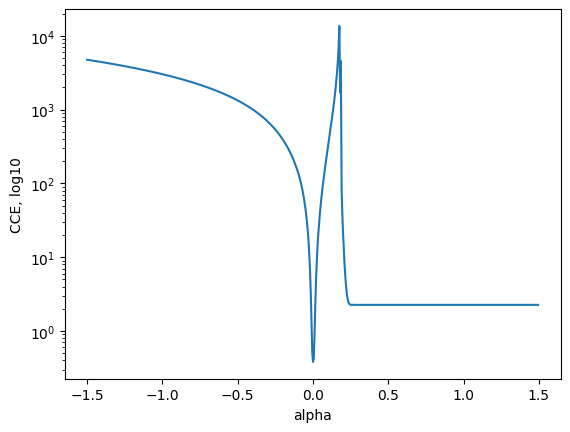

In [21]:
plt.plot(alphas, loss_curve)
plt.yscale('log')
plt.xlabel('alpha')
plt.ylabel('CCE, log10')

## 2D

In [22]:
# увеличив step, можно значительно ускорить вычисления
# однако вместе с этим теряется разрешение
alphas = []
vals = np.arange(-150, 151, step=5)/100
size = vals.size

# создаём заданный растр
for a1 in vals:
    for a2 in vals:
        alphas.append((a1, a2))

alphas = np.array(alphas)

In [23]:
Z = []
for a1, a2 in tqdm(alphas):
    state_dict = model.state_dict()
    # Итерируемся по параметрам (а не по state_dict_backup.items())
    for (name, v), v_new, v_new2 in zip(model.named_parameters(), theta1, theta2):
        # Преобразуем numpy в тензоры
        v_new_t = torch.tensor(v_new, device=device, dtype=torch.float32)
        v_new2_t = torch.tensor(v_new2, device=device, dtype=torch.float32)

        # Линейная интерполяция: сначала по theta1, потом по theta2
        tensor = v.clone().detach() + a1 * (v_new_t - v.clone().detach())
        # ещё раз со вторым вектором
        tensor = tensor + a2 * (v_new2_t - tensor)
        state_dict[name] = tensor
    model.load_state_dict(state_dict)

    loss = []
    with torch.no_grad(): # отключение автоматического дифференцирования
        for inputs, labels in dataloader['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss.append(criterion2(outputs, labels).detach().cpu().numpy())
    Z.append(np.concatenate(loss).mean())
ZZ = np.array(Z)  # (N,) — значения loss для каждой точки сетки

  0%|          | 0/3721 [00:00<?, ?it/s]

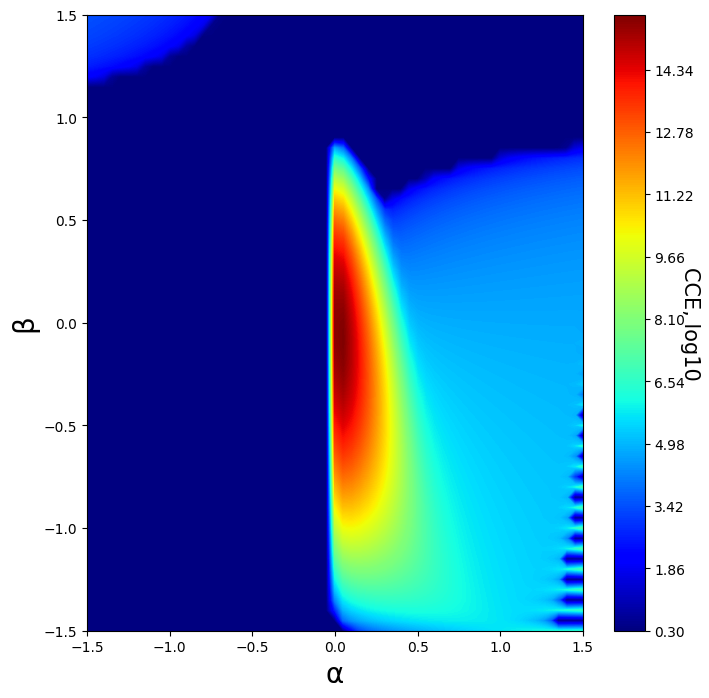

In [24]:
# настройка размера графика
plt.figure(figsize=(8, 8))
# отрисовка закрашенных контуров, аналогично 2 части 1 ЛР
cs = plt.contourf(alphas[:,0].reshape(size, size),
             alphas[:,1].reshape(size, size),
             np.log10(ZZ.reshape(size, size)),
             levels=255,
             cmap=plt.cm.jet,
             )
# установка цветовой шкалы и её названия
plt.colorbar(cs).ax.set_ylabel('CCE, log10', rotation=270, fontsize=15)
# установка названий осям X, Y
plt.xlabel('α', fontsize=20)
plt.ylabel('β', fontsize=20)
plt.show()

## 3D

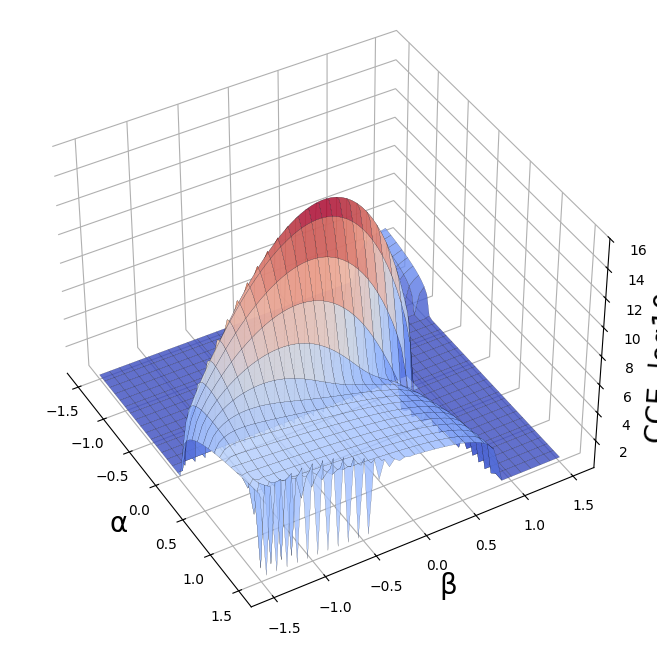

In [25]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "3d"})
# установка названий осям X, Y и Z
ax.set_xlabel('α', fontsize=20)
ax.set_ylabel('β', fontsize=20)
ax.set_zlabel('CCE, log10', fontsize=20)
# выставление прозрачности сетки, для красоты
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
# отрисовка 3D поверхности, данные для отрисовки аналогичны contourf
surf = ax.plot_surface(alphas[:,0].reshape(size, size),
                       alphas[:,1].reshape(size, size),
                       np.log10(ZZ.reshape(size, size)),
                       cmap=plt.cm.coolwarm,
                       linewidth=0.1,
                       edgecolors='k',
                       alpha=0.8,
                       antialiased=True)
# первый агрумент - вращение вокруг XY, второрй аргумент - вокруг YZ
ax.view_init(40, -30)